# Model Training - Gradient Boosting Classifier Model


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score,
    roc_curve
)
from sklearn.base import BaseEstimator, TransformerMixin

from imblearn.over_sampling import SMOTENC

from scipy.stats import randint, uniform

import matplotlib.pyplot as plt
import joblib


In [3]:
# Load your preprocessed file (or raw dataset)
df = pd.read_csv("preprocessed_student_depression(GBC-model).csv")

print(df.shape)
df.head()


(27867, 13)


,Gender,Age,Academic_Pressure,CGPA,Study_Satisfaction,Sleep_Duration,Dietary_Habits,Degree,Suicidal_Thoughts,Study_Hours,Financial_Stress,Mental_Illness_History,Depression
0,Male,33.0,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [4]:
X = df.drop("Depression", axis=1)
y = df["Depression"]


## Data Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((22293, 12), (5574, 12))

## Preprocessing Pipeline

In [25]:
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_indices = [X.columns.get_loc(col) for col in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [21]:
print(categorical_cols.tolist())
print(numeric_cols.tolist())

['Gender', 'Sleep_Duration', 'Dietary_Habits', 'Degree', 'Suicidal_Thoughts', 'Mental_Illness_History']
['Age', 'Academic_Pressure', 'CGPA', 'Study_Satisfaction', 'Study_Hours', 'Financial_Stress']


## Basic GBC

In [ ]:
gb_model = GradientBoostingClassifier(
    random_state=42,
    subsample=0.8,
    max_features='sqrt'
)


## Training Pipeline

In [8]:
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", gb_model)
])


## MODEL 1

### Hyperparameter Tuning

In [9]:
from sklearn.model_selection import StratifiedKFold


param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 3]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best CV score: 0.8483827778963331


### Train Model 1

In [10]:
best_model = grid_search.best_estimator_

### Evaluation

In [45]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Train Accuracy:", best_model.score(X_train, y_train))
print("Test Accuracy :", best_model.score(X_test, y_test))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Train Accuracy: 0.8562777553492128
Test Accuracy : 0.8466092572658773
ROC-AUC Score: 0.9218891545509897

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.80      0.81      2312
           1       0.86      0.88      0.87      3262

    accuracy                           0.85      5574
   macro avg       0.84      0.84      0.84      5574
weighted avg       0.85      0.85      0.85      5574



#### Confusion Matrics

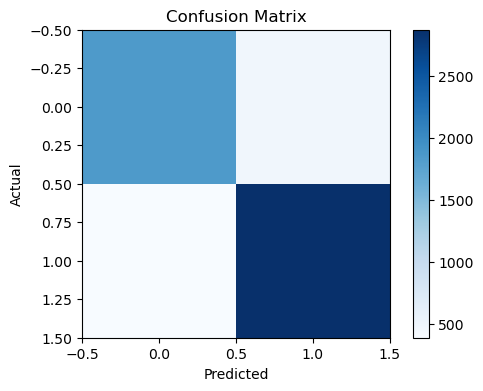

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


#### ROC Curve

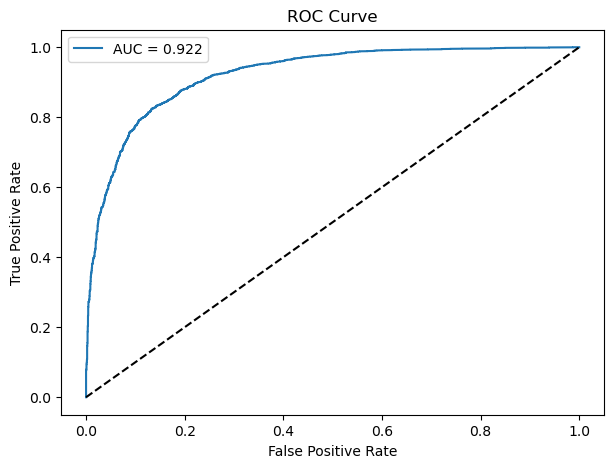

In [13]:
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## MODEL 2

### Apply SMOTENC

In [28]:
sm = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_resampled))

Before SMOTE: [ 9248 13045]
After SMOTE : [13045 13045]


### Hyperparameter Tuning 2

In [39]:
param_distributions = {
    "model__n_estimators": randint(150, 400),
    "model__learning_rate": uniform(0.02, 0.15),
    "model__max_depth": randint(2, 5),
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__subsample": uniform(0.7, 0.3),
    "model__max_features": ["sqrt", "log2", None]
}

In [40]:
cv_strategy = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

In [41]:
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_resampled, y_train_resampled)

print("Best Params:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

Fitting 15 folds for each of 25 candidates, totalling 375 fits


[CV] END model__learning_rate=0.07618101782710437, model__max_depth=2, model__max_features=None, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=338, model__subsample=0.879055047383946; total time=  16.7s
[CV] END model__learning_rate=0.07618101782710437, model__max_depth=2, model__max_features=None, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=338, model__subsample=0.879055047383946; total time=  16.9s
[CV] END model__learning_rate=0.07618101782710437, model__max_depth=2, model__max_features=None, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=338, model__subsample=0.879055047383946; total time=  17.0s
[CV] END model__learning_rate=0.07618101782710437, model__max_depth=2, model__max_features=None, model__min_samples_leaf=3, model__min_samples_split=9, model__n_estimators=338, model__subsample=0.879055047383946; total time=  17.7s
[CV] END model__learning_rate=0.07618101782710437, model__max_depth=2, m

### Model Training 2

In [42]:
best_model_1 = random_search.best_estimator_

y_pred = best_model_1.predict(X_test)
y_prob = best_model_1.predict_proba(X_test)[:, 1]

### Evaluation

In [44]:
print("Train Accuracy:", best_model_1.score(X_train, y_train))
print("Test Accuracy :", best_model_1.score(X_test, y_test))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Train Accuracy: 0.8627371820750909
Test Accuracy : 0.8469680660208109
ROC-AUC Score: 0.9198249105246744

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.81      0.81      2312
           1       0.87      0.87      0.87      3262

    accuracy                           0.85      5574
   macro avg       0.84      0.84      0.84      5574
weighted avg       0.85      0.85      0.85      5574



## Save Model

In [46]:
joblib.dump(best_model, "gbc_model.joblib")

['gbc_model.joblib']